# CNN from scratch: manual 2D convolution as an edge detector

Companion to `notes.md`'s "From-scratch implementation" section. We implement the
convolution formula

$$(I * K)(i, j) = \sum_{m}\sum_{n} I(i+m, j+n)\,K(m, n)$$

directly in NumPy (plain nested loops — the point is to see every multiply-add the
formula describes, not to be fast), apply a small edge-detection kernel to a toy image,
and cross-check the result against `scipy.signal.convolve2d` and `tf.nn.conv2d` to
confirm all three agree.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import tensorflow as tf

np.set_printoptions(precision=3, suppress=True)

I0000 00:00:1787491737.825902  103116 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787491737.826329  103116 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787491738.117282  103116 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787491739.364629  103116 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787491739.365025  103116 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Toy image

A small $8\times8$ grayscale image with a clean vertical step edge: left half dark,
right half bright. A correct vertical-edge detector should light up exactly the column
where the step happens and stay near zero everywhere else.

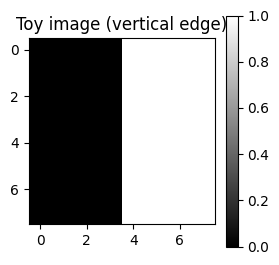

In [2]:
image = np.zeros((8, 8))
image[:, 4:] = 1.0  # bright right half, dark left half -> vertical edge at column 3/4

plt.figure(figsize=(3, 3))
plt.imshow(image, cmap="gray", vmin=0, vmax=1)
plt.title("Toy image (vertical edge)")
plt.colorbar()
plt.show()

## Edge-detection kernel

A classic $3\times3$ vertical Sobel-style kernel: positive weights on the right column,
negative on the left. Wherever the image transitions from dark to bright left-to-right,
the weighted sum spikes; on flat regions it cancels to ~0.

In [3]:
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)
kernel

array([[-1.,  0.,  1.],
       [-2.,  0.,  2.],
       [-1.,  0.,  1.]])

## Manual 2D convolution (nested loops, `"valid"` padding)

Exactly `notes.md`'s formula: slide the kernel over every position where it fully
overlaps the image (no padding, stride 1 — `"valid"` mode), and at each position sum
the element-wise product of the kernel and the underlying image patch. Output size is
$(n-k)/s + 1 = (8-3)/1 + 1 = 6$ per side, matching `notes.md`'s padding formula.

In [4]:
def conv2d_manual(I, K):
    kh, kw = K.shape
    ih, iw = I.shape
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = I[i:i + kh, j:j + kw]
            out[i, j] = np.sum(patch * K)  # elementwise product, then sum
    return out

feature_map_manual = conv2d_manual(image, kernel)
feature_map_manual

array([[0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.]])

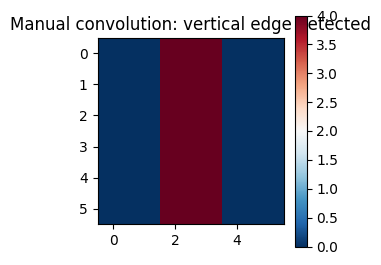

In [5]:
plt.figure(figsize=(3, 3))
plt.imshow(feature_map_manual, cmap="RdBu_r")
plt.title("Manual convolution: vertical edge detected")
plt.colorbar()
plt.show()

## Cross-check against `scipy.signal.convolve2d`

`scipy`'s convolution flips the kernel (true mathematical convolution) whereas
`notes.md`'s formula and CNN frameworks actually implement **cross-correlation** (no
flip) — the two only agree if the kernel is passed pre-flipped, or if `correlate2d` is
used instead. We use `convolve2d` with an explicitly flipped kernel to match the
manual (unflipped, cross-correlation-style) computation above exactly.

In [6]:
feature_map_scipy = convolve2d(image, kernel[::-1, ::-1], mode="valid")
print("Manual vs scipy match:", np.allclose(feature_map_manual, feature_map_scipy))
feature_map_scipy

Manual vs scipy match: True


array([[0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.]])

## Cross-check against `tf.nn.conv2d`

TensorFlow's `conv2d` (like every deep learning framework) performs cross-correlation,
no kernel flip — the same convention the manual loop above uses, and the same
convention `notes.md`'s formula describes. Reshape image/kernel into TF's expected
`(batch, height, width, channels)` / `(kh, kw, in_channels, out_channels)` layouts.

In [7]:
image_tf = image.reshape(1, 8, 8, 1).astype(np.float32)
kernel_tf = kernel.reshape(3, 3, 1, 1).astype(np.float32)

feature_map_tf = tf.nn.conv2d(image_tf, kernel_tf, strides=1, padding="VALID").numpy()[0, :, :, 0]
print("Manual vs tf.nn.conv2d match:", np.allclose(feature_map_manual, feature_map_tf, atol=1e-5))
feature_map_tf

Manual vs tf.nn.conv2d match: True


E0000 00:00:1787491740.083980  103116 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787491740.084465  103180 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787491740.207530  103116 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


array([[0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.],
       [0., 0., 4., 4., 0., 0.]], dtype=float32)

## Side-by-side

All three computations — hand-written nested loops, `scipy.signal.convolve2d`, and
`tf.nn.conv2d` — should produce the same feature map: near-zero on flat regions, a
sharp response at the column where the edge sits.

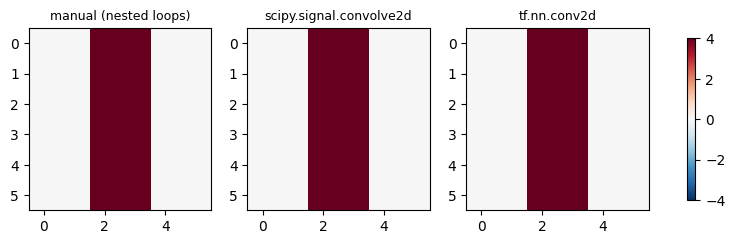

All three implementations agree.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, fm, title in zip(
    axes,
    [feature_map_manual, feature_map_scipy, feature_map_tf],
    ["manual (nested loops)", "scipy.signal.convolve2d", "tf.nn.conv2d"],
):
    im = ax.imshow(fm, cmap="RdBu_r", vmin=-4, vmax=4)
    ax.set_title(title, fontsize=9)
fig.colorbar(im, ax=axes, shrink=0.7)
plt.show()

assert np.allclose(feature_map_manual, feature_map_scipy)
assert np.allclose(feature_map_manual, feature_map_tf, atol=1e-5)
print("All three implementations agree.")

## Takeaway

Reading `notes.md`'s convolution formula and computing it by hand with two nested
loops produces exactly the same feature map that `scipy` and `tf.nn.conv2d` compute
internally (once the flip-vs-no-flip convention is matched). A `Conv2D` layer's forward
pass is this operation repeated for every learnable kernel in the layer, applied at
every spatial position — the only thing training adds is that the kernel values
themselves (here fixed, hand-picked Sobel weights) become parameters learned by
backpropagation, the same gradient-descent mechanism derived in `01-ann/notes.md`.